# What is the probibility of drawing a pair of aces in Texas Holdem? Assuming there are 4 players, the dealing is round robin, and you recieve first.

This study will be a prospective, observational study. The sample space I am observing is all of the cards in a standard deck so 52. One trial of the simulation is one dealing rotation. I am measuring instances of a pair of aces being dealt.

In [18]:
import random, seaborn

In [2]:
def genDeck():
    deck = [
        ("2", "Hearts"), ("3", "Hearts"), ("4", "Hearts"), ("5", "Hearts"), ("6", "Hearts"),
        ("7", "Hearts"), ("8", "Hearts"), ("9", "Hearts"), ("10", "Hearts"),
        ("Jack", "Hearts"), ("Queen", "Hearts"), ("King", "Hearts"), ("Ace", "Hearts"),
    
        ("2", "Diamonds"), ("3", "Diamonds"), ("4", "Diamonds"), ("5", "Diamonds"), ("6", "Diamonds"),
        ("7", "Diamonds"), ("8", "Diamonds"), ("9", "Diamonds"), ("10", "Diamonds"),
        ("Jack", "Diamonds"), ("Queen", "Diamonds"), ("King", "Diamonds"), ("Ace", "Diamonds"),
    
        ("2", "Clubs"), ("3", "Clubs"), ("4", "Clubs"), ("5", "Clubs"), ("6", "Clubs"),
        ("7", "Clubs"), ("8", "Clubs"), ("9", "Clubs"), ("10", "Clubs"),
        ("Jack", "Clubs"), ("Queen", "Clubs"), ("King", "Clubs"), ("Ace", "Clubs"),
    
        ("2", "Spades"), ("3", "Spades"), ("4", "Spades"), ("5", "Spades"), ("6", "Spades"),
        ("7", "Spades"), ("8", "Spades"), ("9", "Spades"), ("10", "Spades"),
        ("Jack", "Spades"), ("Queen", "Spades"), ("King", "Spades"), ("Ace", "Spades")
    ]
    return deck

In [3]:
def simDealing(numP):
    deck = genDeck()
    random.shuffle(deck)

    hands = [[] for _ in range(numP)]
    
    for i, card in enumerate(deck):
        hands[i % numP].append(card)
    
    return hands

In [20]:
numSims = 100000
results = []
numAces = 0
for _ in range(numSims):
    hands = simDealing(4)

    if "Ace" in hands[0][0] and "Ace" in hands[0][1]:
        results.append("Pocket Aces")
        numAces+= 1
    else:
        results.append("Other")

odds = str(numAces/numSims*100)
print(odds+"%")

0.42700000000000005%


/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


<Axes: ylabel='count'>

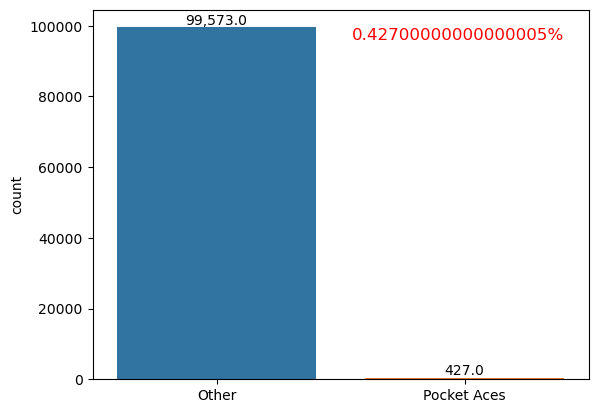

In [21]:
ax = seaborn.countplot(x = results)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black')
ax.text(0.95, 0.95, odds + "%",
        horizontalalignment='right',
        verticalalignment='top',
        transform=ax.transAxes,
        fontsize=12,
        color="red")
ax

The empirical probability is 0.427% and the theorhetical probability of 0.4524%. These values are very close to each other so it can be concluded that the probibility of drawing a pair of aces in Texas Holdem is 0.4524%.